#
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>Partie 1 : Définition du problème</h2>
    <div class="accent-line"></div>
</div>
La **classification** est un type d’**apprentissage supervisé** utilisé pour prédire une **valeur catégorielle**, la classification permet de répondre à la question de : *« Le client va-t-il quitter la banque ou non ? »*.

Dans ce projet, nous utilisons un **jeu de données de clients bancaires (Customer Churn Dataset)** contenant des informations sur les clients ainsi que leur statut de départ.

- **10 000 lignes (clients)**
- **14 colonnes (variables explicatives + variable cible)**
- **Variable cible :** `Exited`  
  (1 = le client a quitté la banque, 0 = le client est resté)

---

## Aperçu des variables

- **Variables numériques :** CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary  
- **Variables catégorielles :** Geography, Gender  
- **Variables binaires :** HasCrCard, IsActiveMember  

---

## Objectif

L’objectif est de **prédire si un client va quitter la banque** en se basant sur plusieurs caractéristiques :

1. **CreditScore :** Score de crédit du client  
2. **Geography :** Pays du client (France, Espagne, Allemagne)  
3. **Gender :** Sexe du client  
4. **Age :** Âge du client  
5. **Tenure :** Ancienneté (en années)  
6. **Balance :** Solde du compte  
7. **NumOfProducts :** Nombre de produits bancaires utilisés  
8. **HasCrCard :** Possession d’une carte de crédit  
9. **IsActiveMember :** Activité du client  
10. **EstimatedSalary :** Salaire estimé  

---

## 🎯 But du projet

Construire un **modèle de classification** capable de prédire :

➡️ **Si un client va quitter la banque (`Exited = 1`) ou rester (`Exited = 0`)**

## Description des variables

| Variable           | Type        | Description |
|------------------|------------|------------|
| RowNumber        | Numérique  | Numéro de la ligne |
| CustomerId       | Numérique  | Identifiant unique du client |
| Surname          | Catégorielle | Nom du client |
| CreditScore      | Numérique  | Score de crédit |
| Geography        | Catégorielle | Pays du client |
| Gender           | Catégorielle | Sexe du client |
| Age              | Numérique  | Âge du client |
| Tenure           | Numérique  | Ancienneté (années) |
| Balance          | Numérique  | Solde bancaire |
| NumOfProducts    | Numérique  | Nombre de produits |
| HasCrCard        | Binaire    | Possède une carte de crédit (0/1) |
| IsActiveMember   | Binaire    | Client actif (0/1) |
| EstimatedSalary  | Numérique  | Salaire estimé |
| Exited           | Binaire    | Client parti (1) ou resté (0) |

#
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>partie 2 : importation des donnees</h2>
    <div class="accent-line"></div>
</div>


In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 

In [3]:
df=pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# 
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>partie 3 : data cleaning </h2>
    <div class="accent-line"></div>
</div>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>detectation des outliers avec boxplot</h2>
    <div class="accent-line"></div>
</div>

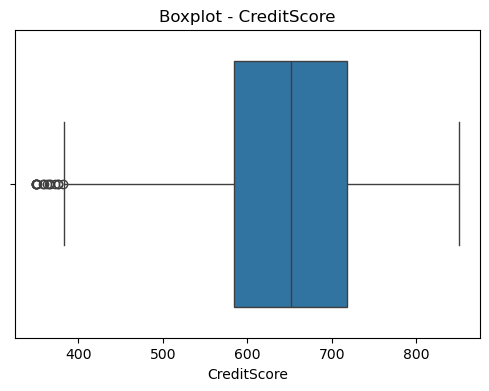

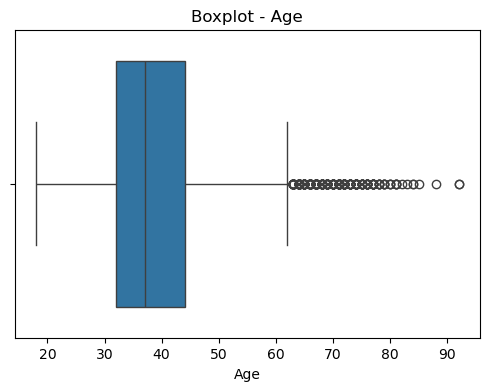

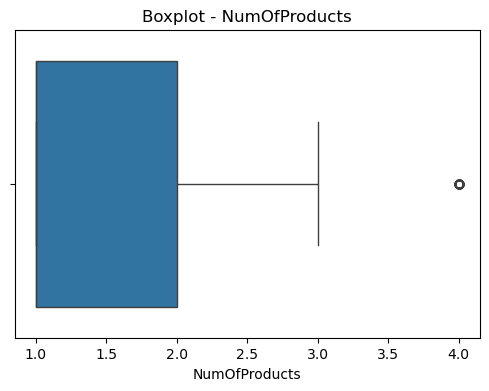

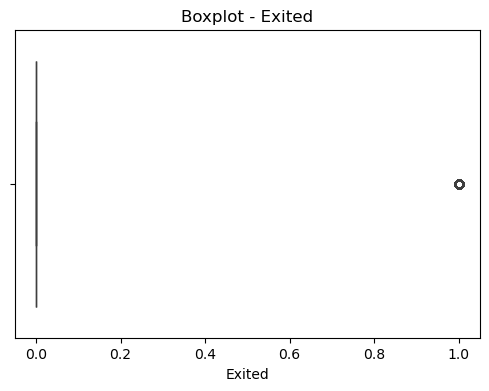

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df[['CreditScore','Age','NumOfProducts','Exited']]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()  

In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #fcfcfc; color: #000000; padding: 20px; border: 1px solid #b3beff; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h3 style="color: #471bd8; border-bottom: 2px solid #7c4dff; padding-bottom: 8px; margin-top: 0;">
         Interprétation des Boxplots (Analyse des Outliers)
    </h3> 
    <p style="font-size: 15px; line-height: 1.6;">
        À première vue, les boxplots montrent la présence de quelques <strong>"points atypiques" (outliers)</strong> dans certaines variables. Cependant, en analysant le contexte métier (domaine bancaire), nous pouvons conclure que <strong>ces valeurs sont tout à fait naturelles et ne représentent pas des erreurs de données</strong>.
    </p>
    <ul style="list-style-type: none; padding: 0; margin: 15px 0 0 0;">
        <li style="background-color: #e6e9ff; padding: 12px; margin-bottom: 8px; border-left: 5px solid #5c4dff; border-radius: 4px;">
            <strong>👤 Age :</strong> Les valeurs au-dessus de la moustache supérieure (60 à 90 ans) représentent simplement une clientèle senior. C'est une situation démographique normale.
        </li>
        <li style="background-color: #ffffff; padding: 12px; margin-bottom: 8px; border-left: 5px solid #4d65ff; border-radius: 4px; border-top: 1px solid #b3b8ff; border-right: 1px solid #c1b3ff; border-bottom: 1px solid #b3b4ff;">
            <strong>📉 CreditScore :</strong> Les quelques points en dessous de 400 indiquent des clients avec un très mauvais historique de crédit. C'est une information cruciale pour notre modèle, pas une anomalie.
        </li>
        <li style="background-color: #e6e7ff; padding: 12px; margin-bottom: 0; border-left: 5px solid #774dff; border-radius: 4px;">
            <strong>💳 NumOfProducts :</strong> La valeur 4 apparaît comme un outlier car la majorité des clients ont 1 ou 2 produits. Avoir 4 produits reste une réalité commerciale rare mais valide.
        </li>
    </ul>
    <p style="font-size: 15px; margin-top: 15px; font-weight: bold; color: #d32f2f;">
        👉 Conclusion : Aucun traitement (suppression ou imputation) n'est nécessaire pour ces valeurs extrêmes. Elles seront conservées pour l'entraînement du modèle.
    </p>
</div>

## DATA is clean ✅ 

# 
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>Partie 4 : Analyse exploratoire des données (EDA)</h2>
    <div class="accent-line"></div>
</div>





### 4. Analyse des variables catégorielles

Nous analysons :
- Gender vs Exited  
- Geography vs Exited  

👉 Cela permet de voir si certaines catégories sont plus susceptibles de quitter.

---

### 5. Corrélation entre les variables

Nous utilisons une matrice de corrélation pour identifier les relations entre variables numériques.

---

### Conclusion de l’analyse

- La variable cible est déséquilibrée  
- L’âge influence fortement le churn  
- Les clients en Allemagne quittent plus  
- Les clients inactifs sont plus susceptibles de partir  

👉 Ces observations guideront les étapes suivantes (cleaning et preprocessing).

### 1. Analyse de la variable cible

Nous commençons par analyser la distribution de la variable cible `Exited`.

👉 Cela permet de vérifier si les classes sont équilibrées ou non.

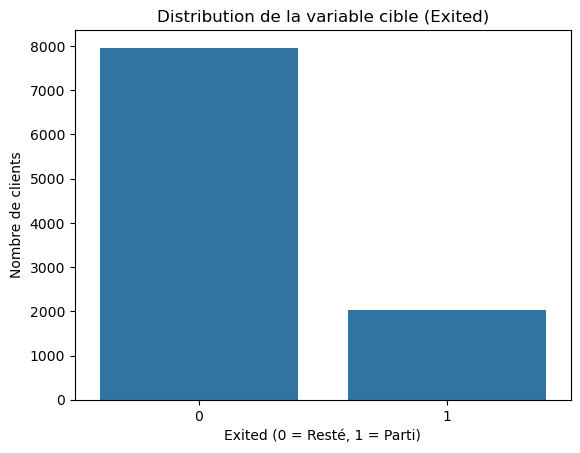

In [11]:
# Distribution de la variable cible
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)
plt.title("Distribution de la variable cible (Exited)")
plt.xlabel("Exited (0 = Resté, 1 = Parti)")
plt.ylabel("Nombre de clients")
plt.show()

### 2. Relation entre les variables et le churn

Nous analysons l’impact de certaines variables sur le churn :

- Gender vs Exited  
- Geography vs Exited  
- NumOfProducts vs Exited  

👉 Cela permet d’identifier les facteurs influençant le départ des clients.



#### – Les hommes quittent-ils plus la banque que les femmes (ou inversement) ?

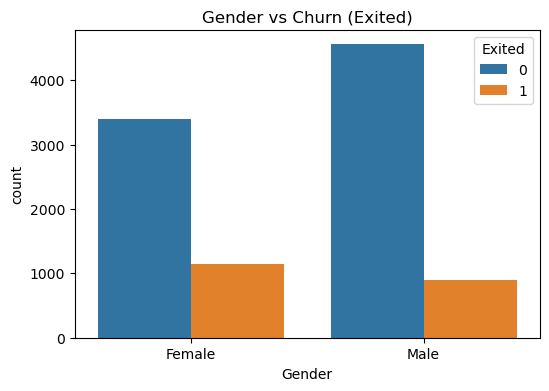

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender vs Churn (Exited)")
plt.show()



*Le genre a un impact léger sur le churn, avec une tendance légèrement plus élevée chez les femmes*

#### – Quel pays a le taux de churn le plus élevé ?

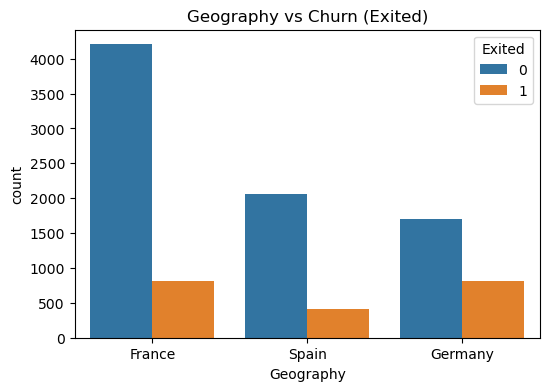

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Churn (Exited)")
plt.show()


*La geographie a une impact léger sur le churn, avec une tendance chez 'France'*

#### – Est-ce que le nombre de produits influence le churn (Exited)

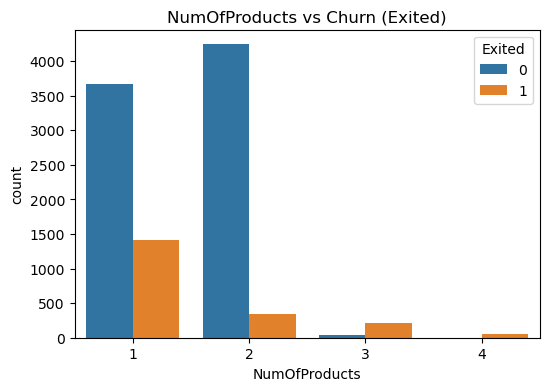

In [14]:

plt.figure(figsize=(6,4))
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title("NumOfProducts vs Churn (Exited)")
plt.show()

*Le nombre de produits influence légerement sur le churn*

In [15]:
df.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


### 2. Distribution de churn selon:

Nous analysons l’impact de certaines variables sur le churn :

- Credit Score  
- Balance
- Estimated Salary  

👉 Cela permet d’identifier les facteurs influençant le départ des clients.

#### – Credit Score

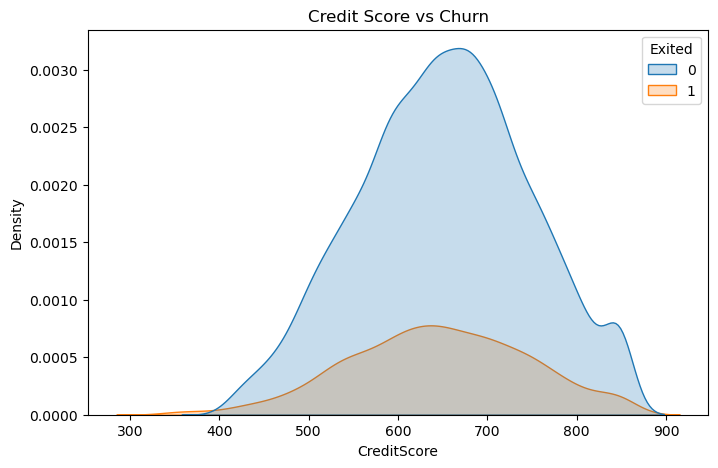

In [16]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='CreditScore', hue='Exited', fill=True)
plt.title("Credit Score vs Churn")
plt.show()

*Le Credit Score peut influencer légèrement le churn*

#### – Balance

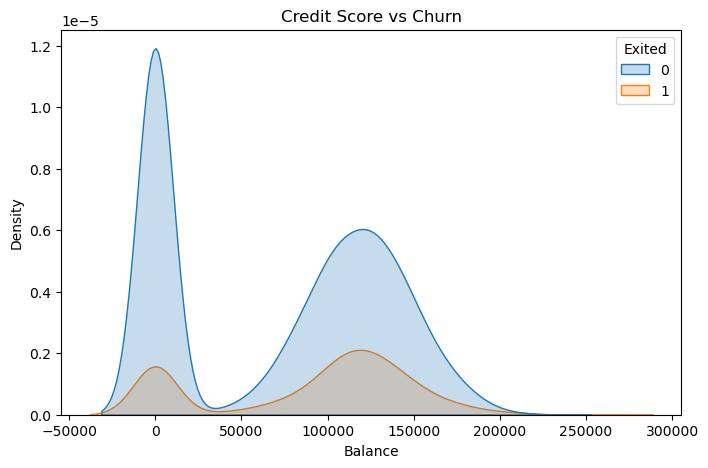

In [17]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Balance', hue='Exited', fill=True)
plt.title("Credit Score vs Churn")
plt.show()

*- Le Balance semble avoir une relation plus visible avec le départ des clients*

#### – Estimated Salary

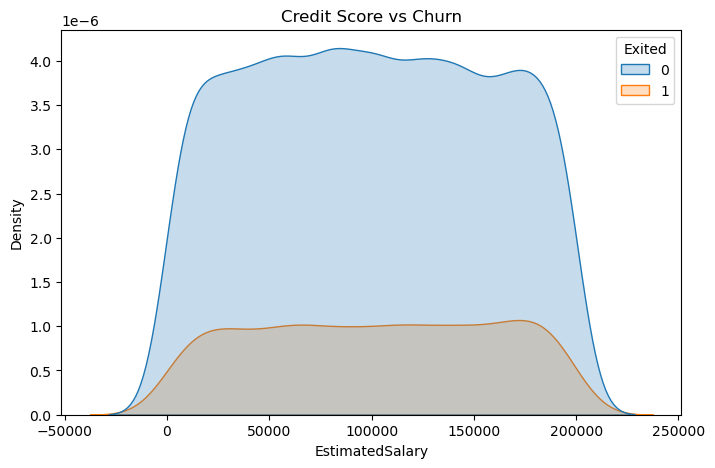

In [18]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='EstimatedSalary', hue='Exited', fill=True)
plt.title("Credit Score vs Churn")
plt.show()

# 
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>Partie 5 : Data Preprocessing</h2>
    <div class="accent-line"></div>
</div>




In [19]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2> Encodage des Variables Catégoriques</h2>
    <div class="accent-line"></div>
</div>

In [20]:
cat_cols = ['Geography', 'Gender']

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,0.0,0.0,0.0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0,0.0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0,0.0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,0.0,0.0,0.0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0,0.0


<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>Mise à l'Échelle des Données</h2>
    <div class="accent-line"></div>
</div>

In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scaling
scaler = StandardScaler()
df[['CreditScore', 'Balance','EstimatedSalary']] = scaler.fit_transform(df[['CreditScore', 'Balance','EstimatedSalary']])

# Encoding target
encoder = LabelEncoder()
df['Exited'] = encoder.fit_transform(df['Exited'])
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,-0.326221,42,2,-1.225848,1,1,1,0.021886,1,0.0,0.0,0.0
1,2,15647311,Hill,-0.440036,41,1,0.117350,1,0,1,0.216534,0,0.0,1.0,0.0
2,3,15619304,Onio,-1.536794,42,8,1.333053,3,1,0,0.240687,1,0.0,0.0,0.0
3,4,15701354,Boni,0.501521,39,1,-1.225848,2,0,0,-0.108918,0,0.0,0.0,0.0
4,5,15737888,Mitchell,2.063884,43,2,0.785728,1,1,1,-0.365276,0,0.0,1.0,0.0


In [22]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['TenureByAge'] = df['Tenure'] / (df['Age'] + 1)
df['AgeScore'] = df['Age'] * df['NumOfProducts']
df['CreditScoreByAge'] = df['CreditScore'] / (df['Age'] + 1)
df['IsSenior'] = (df['Age'] >= 45).astype(int)
df['HasBalance'] = (df['Balance'] > 0).astype(int)
df['ActiveWithCard'] = df['IsActiveMember'] * df['HasCrCard']

# Code snippet quick l had l-features:
df['Balance_per_Tenure'] = df['Balance'] / (df['Tenure'] + 1) # +1 bach n-evitaw l-9isma 3la 0

# Zid had les features f l-DataFrame dyalk (df)
df['Balance_to_Salary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
# 1. Tnasob d l-flous: Wach l-client 3ando crédit m9arnat b l-flous li 7at f l-banka?

# 2. Interaction d l-3mer m3a les produits: Les clients li kbar f l-3mer o 3andhom bzaf d les produits homa li kay-churnew bzaf

# 3. Score d l-fidélité sghira: L-3mer m3a tenure
df['Age_per_Tenure'] = df['Age'] / (df['Tenure'] + 1)


# 
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>partie 6 : model training </h2>
    <div class="accent-line"></div>
</div>

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>Séparation en Train et Test</h2>
    <div class="accent-line"></div>
</div>

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ["Surname" , "CustomerId","RowNumber","Exited"])
Y = df["Exited"]


<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>SMOTE</h2>
    <div class="accent-line"></div>
</div>

In [24]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(sampling_strategy=0.90, k_neighbors=5, random_state=42)
X, y = smote.fit_resample(X, Y)

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>logistique regression</h2>
    <div class="accent-line"></div>
</div>

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, stratify=y)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
y.value_counts()

Exited
0    7963
1    7166
Name: count, dtype: int64

In [28]:
Logistic = LogisticRegression()
Logistic.fit(X_train, y_train)
y_pred_log = Logistic.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Matrice de confusion:\n", confusion_matrix(y_test, y_pred_log)) 
print("Rapport de classification:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.7544613350958361
Matrice de confusion:
 [[1254  339]
 [ 404 1029]]
Rapport de classification:
               precision    recall  f1-score   support

           0       0.76      0.79      0.77      1593
           1       0.75      0.72      0.73      1433

    accuracy                           0.75      3026
   macro avg       0.75      0.75      0.75      3026
weighted avg       0.75      0.75      0.75      3026



Text(70.72222222222221, 0.5, 'Valeur reelle')

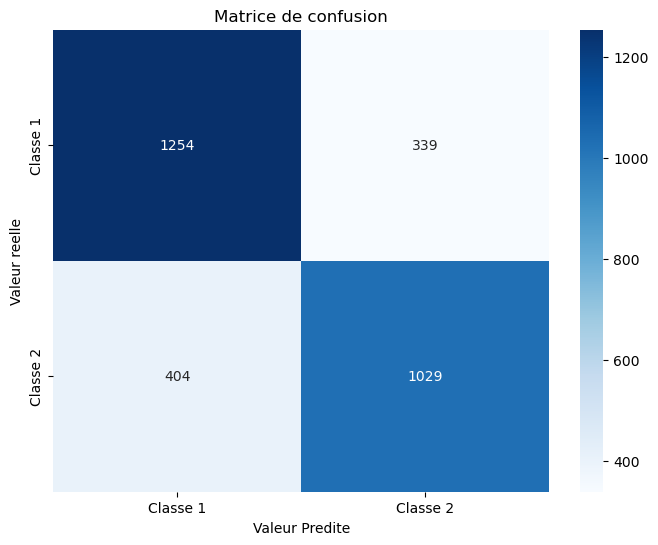

In [29]:
cm=confusion_matrix(y_test,y_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True ,fmt='d', cmap="Blues",
            xticklabels=['Classe 1','Classe 2'],
            yticklabels=['Classe 1','Classe 2']) 

plt.title('Matrice de confusion')
plt.xlabel('Valeur Predite')
plt.ylabel('Valeur reelle')

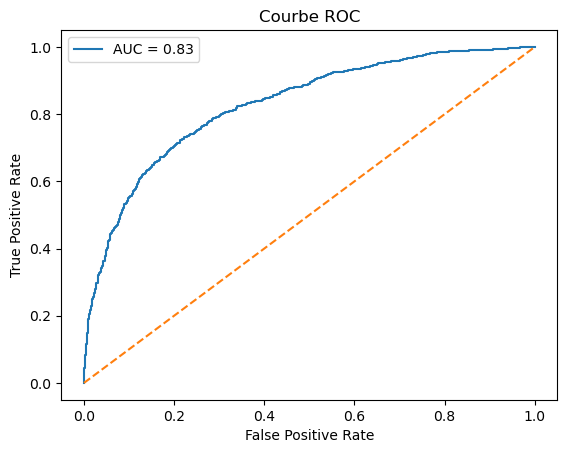

In [30]:
from sklearn.metrics import roc_curve, auc

y_proba = Logistic.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # ligne diagonale

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()

plt.show()

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>
<div class="eda-header">
    <h2>KNN classifier</h2>
    <div class="accent-line"></div>
</div>

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)


In [33]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [34]:
y_pred_knn = knn.predict(X_test)

In [35]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.2f}") 
print("Matrice de Confusion :\n", confusion_matrix(y_test, y_pred_knn)) 
print("Rapport de Classification :\n", classification_report(y_test, y_pred_knn))

Accuracy : 0.83
Matrice de Confusion :
 [[1293  300]
 [ 229 1204]]
Rapport de Classification :
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1593
           1       0.80      0.84      0.82      1433

    accuracy                           0.83      3026
   macro avg       0.83      0.83      0.83      3026
weighted avg       0.83      0.83      0.83      3026



Text(70.72222222222221, 0.5, 'Valeur reelle')

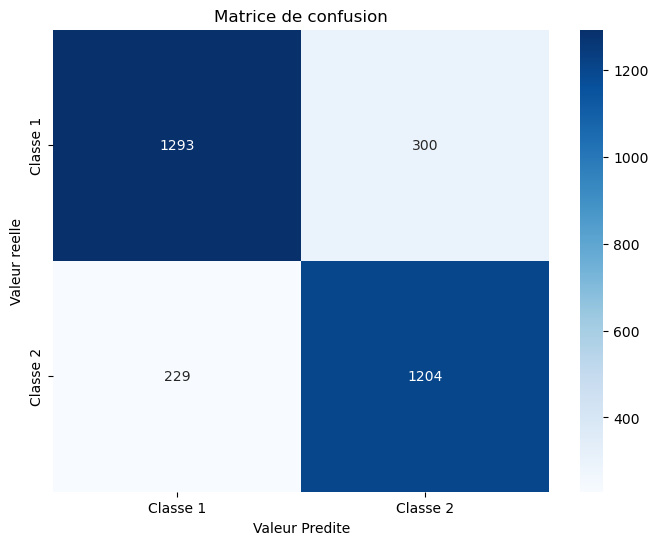

In [36]:
cm=confusion_matrix(y_test,y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True ,fmt='d', cmap="Blues",
            xticklabels=['Classe 1','Classe 2'],
            yticklabels=['Classe 1','Classe 2']) 

plt.title('Matrice de confusion')
plt.xlabel('Valeur Predite')
plt.ylabel('Valeur reelle')

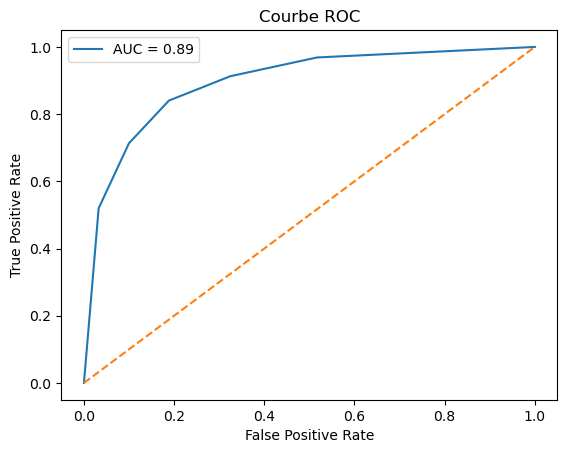

In [37]:
y_proba = knn.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # ligne diagonale

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()

plt.show()

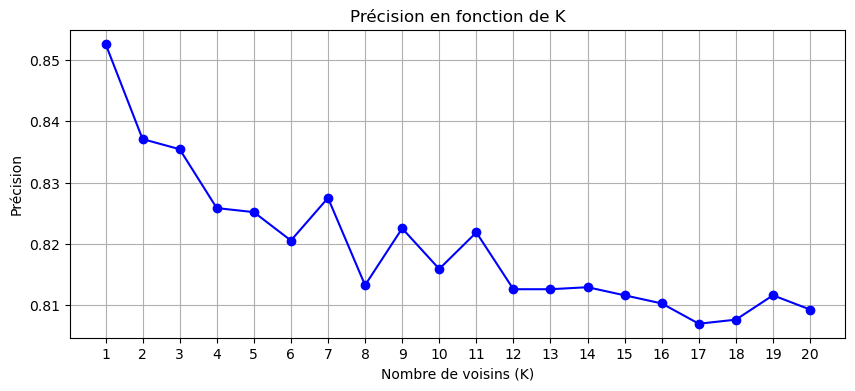

In [38]:
accuracies = []

# Tester différents K
k_values = range(1, 21)
for k in k_values:
     knn = KNeighborsClassifier(n_neighbors=k)
     knn.fit(X_train, y_train)
     y_pred = knn.predict(X_test)
     accuracies.append(accuracy_score(y_test, y_pred))

# Visualisation
plt.figure(figsize=(10, 4))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title("Précision en fonction de K")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Précision")
plt.xticks(k_values)
plt.grid()
plt.show()

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>Decision Tree</h2>
    <div class="accent-line"></div>
</div>

In [39]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

mdl = DecisionTreeClassifier(criterion = "gini", max_depth = 10, random_state = 42)
mdl.fit(X_train, y_train)

y_pred_mdl = mdl.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matrice de confusion:\n", confusion_matrix(y_test, y_pred)) 
print("Rapport de classification:\n", classification_report(y_test, y_pred))

Accuracy: 0.8093192333113021
Matrice de confusion:
 [[1347  246]
 [ 331 1102]]
Rapport de classification:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82      1593
           1       0.82      0.77      0.79      1433

    accuracy                           0.81      3026
   macro avg       0.81      0.81      0.81      3026
weighted avg       0.81      0.81      0.81      3026



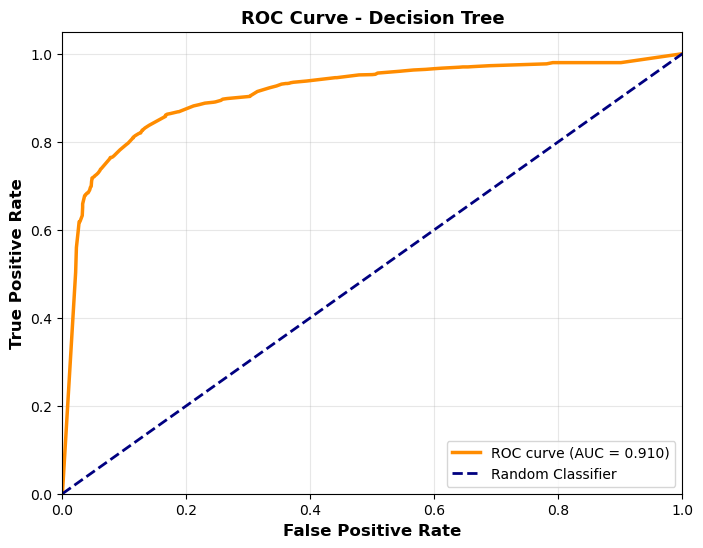

In [42]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve for Decision Tree
y_proba_dt = mdl.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc_dt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Decision Tree', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

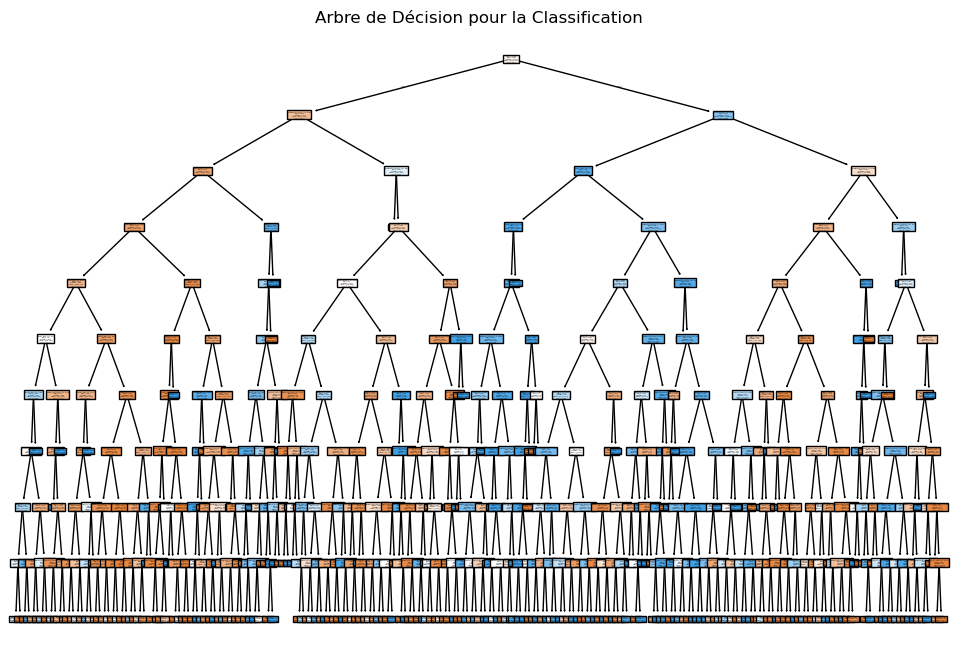

In [43]:
plt.figure(figsize=(12, 8))
tree.plot_tree(mdl, filled=True, feature_names=X.columns, class_names=['stayed', 'Exited'])

plt.title("Arbre de Décision pour la Classification")
plt.show()


Analyse de l'Arbre de Décision
Cet arbre de décision prédit si un client va rester (stayed) ou partir (Exited).

1. Comprendre les nœuds
Condition (ex: Age <= 44.5) : La règle de séparation. Vrai (True) à gauche, Faux (False) à droite.

gini : Mesure la pureté du nœud. Plus c'est proche de 0, plus la prédiction est claire.

samples / value : Nombre total de clients dans le nœud et leur répartition [restés, partis].

class : La prédiction finale (la majorité) pour ce groupe.

2. Code Couleurs
Orange : La majorité des clients restent (stayed).

Bleu : La majorité des clients quittent (Exited).

Plus la couleur est foncée, plus l'algorithme est sûr.

3. Conclusions Clés
L'Âge est le critère numéro 1 : La première séparation se fait à 44.5 ans.

Clients < 44.5 ans (Gauche) : Ils ont tendance à rester, sauf s'ils possèdent plus de 2 produits (risque de départ).

Clients > 44.5 ans (Droite) : L'activité est déterminante.

Inactifs : Fort risque de départ (surtout entre 44.5 et 51.5 ans).

Actifs : Ont tendance à rester, sauf s'ils ont plus de 2 produits.

En résumé : Les clients fidèles ont généralement moins de 45 ans avec 1 ou 2 produits. Les clients à risque sont ceux de plus de 45 ans inactifs, ou ceux ayant plus de 2 produits.

#
<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>random forest</h2>
    <div class="accent-line"></div>
</div>


Les forêts aléatoires sont une méthode d'apprentissage d'ensemble pour la classification qui opère en construisant une multitude d'arbres de décision lors de la formation. La prédiction finale est le vote majoritaire des arbres individuels. Cette approche permet de réduire le surapprentissage (overfitting) par rapport à un arbre de décision unique.


In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
rf_classifier = RandomForestClassifier(n_estimators=180, criterion = "entropy",max_depth=24, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=24, n_estimators=180,
                       random_state=42)

In [46]:
y_pred_rf = rf_classifier.predict(X_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Matrice de confusion:\n", confusion_matrix(y_test, y_pred_rf)) 
print("Rapport de classification:\n", classification_report(y_test, y_pred_rf))


Accuracy: 0.8955717118307998
Matrice de confusion:
 [[1476  117]
 [ 199 1234]]
Rapport de classification:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      1593
           1       0.91      0.86      0.89      1433

    accuracy                           0.90      3026
   macro avg       0.90      0.89      0.89      3026
weighted avg       0.90      0.90      0.90      3026



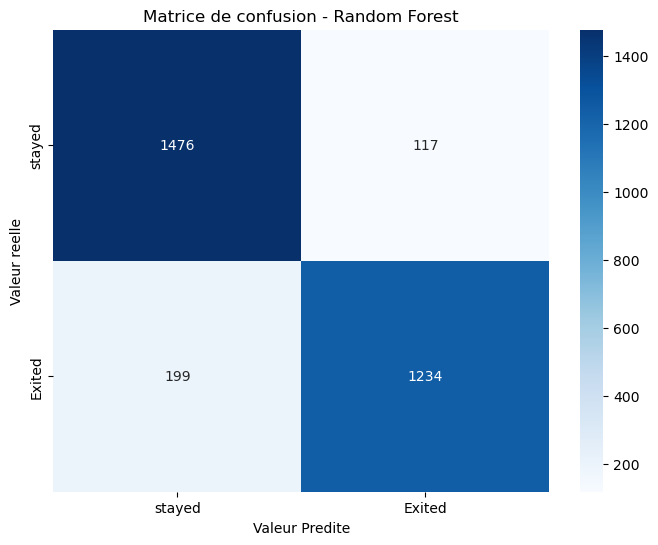

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True ,fmt='d', cmap="Blues",
            xticklabels=['stayed', 'Exited'],
            yticklabels=['stayed', 'Exited']) 

plt.title('Matrice de confusion - Random Forest')
plt.xlabel('Valeur Predite')
plt.ylabel('Valeur reelle')
plt.show()


### Interprétation: Importance des caractéristiques (Feature Importance)

L'importance des caractéristiques mesure à quel point chaque variable contribue à réduire l'impureté dans l'ensemble des arbres de la forêt. Les variables avec une importance plus élevée sont les facteurs déterminants dans les prédictions du modèle.


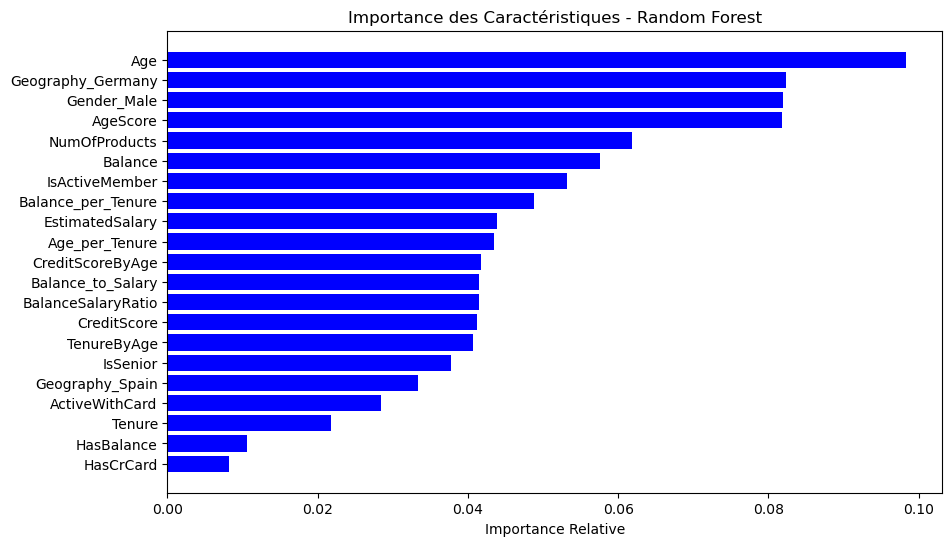

In [49]:
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Importance des Caractéristiques - Random Forest")
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importance Relative')
plt.show()


### Interprétation: Visualisation d'un arbre individuel

Puisqu'une forêt aléatoire est une collection d'arbres, nous pouvons extraire et visualiser l'un d'entre eux (par exemple, le tout premier, le "voter" numéro 0) pour mieux comprendre son fonctionnement interne. Nous limitons la profondeur à 3 pour la lisibilité.


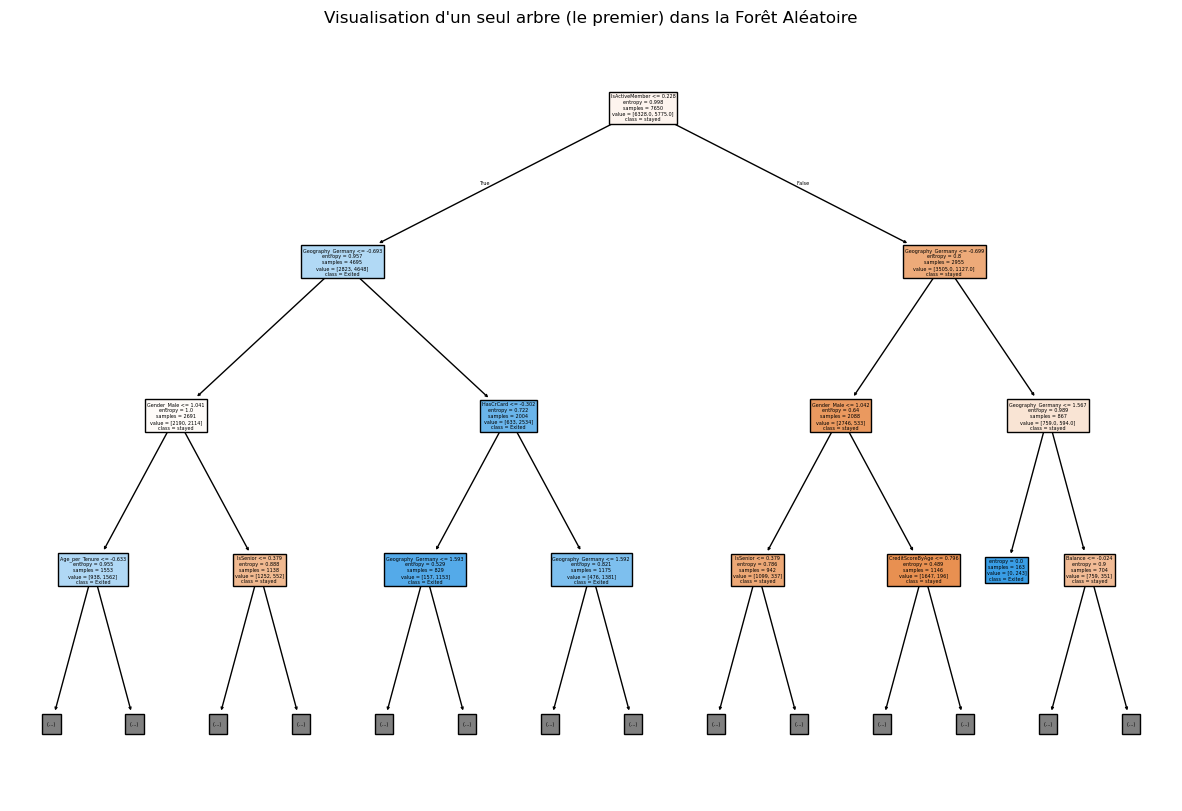

In [50]:
plt.figure(figsize=(15, 10))
single_tree = rf_classifier.estimators_[0]
tree.plot_tree(single_tree, max_depth=3, filled=True, feature_names=X.columns, class_names=['stayed', 'Exited'])
plt.title("Visualisation d'un seul arbre (le premier) dans la Forêt Aléatoire")
plt.show()


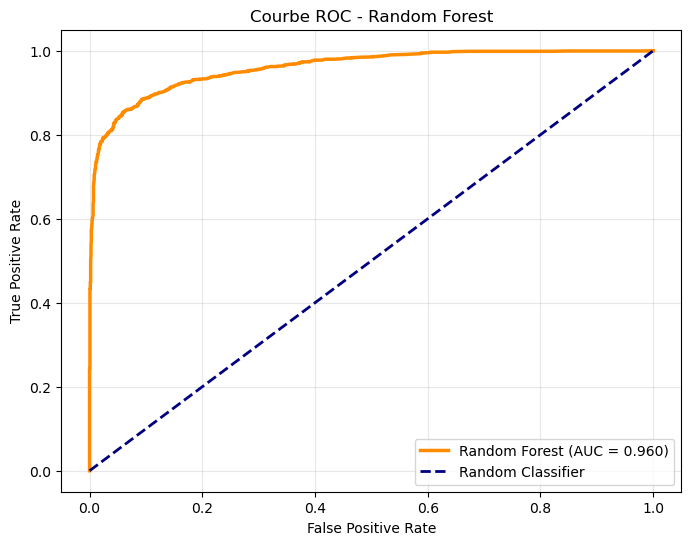

In [51]:
y_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2.5, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [52]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SVM_ = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

SVM_.fit(X_train, y_train)

Y_pred_svm = SVM_.predict(X_test)



In [53]:
print(confusion_matrix(y_test, Y_pred_svm))
print(classification_report(y_test, Y_pred_svm))

[[1441  152]
 [ 305 1128]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1593
           1       0.88      0.79      0.83      1433

    accuracy                           0.85      3026
   macro avg       0.85      0.85      0.85      3026
weighted avg       0.85      0.85      0.85      3026



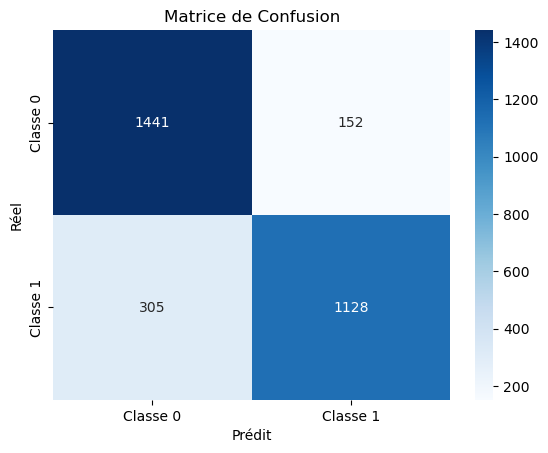

In [54]:
conf_matrix = confusion_matrix(y_test, Y_pred_svm)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=['Classe 0', 'Classe 1'],yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

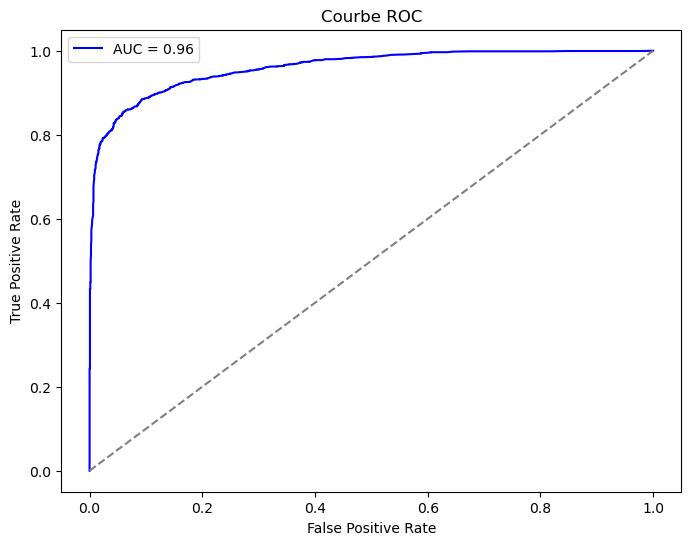

In [55]:
# Calcul de la courbe ROC
if hasattr(SVM_, "predict_proba"):
	y_scores = SVM_.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>model comparison</h2>
    <div class="accent-line"></div>
</div>

In [56]:
model_accuracies = {
     "Logistic Regression": accuracy_score(y_test, y_pred_log),
     "KNN": accuracy_score(y_test, y_pred_knn),
     "Decision Tree": accuracy_score(y_test, y_pred_mdl),
     "Random Forest": accuracy_score(y_test, y_pred_rf),
     "SVM": accuracy_score(y_test, Y_pred_svm)
}

for model_name, acc in model_accuracies.items():
     print(f"Accuracy de {model_name} : {acc:.2f}")

Accuracy de Logistic Regression : 0.75
Accuracy de KNN : 0.83
Accuracy de Decision Tree : 0.85
Accuracy de Random Forest : 0.90
Accuracy de SVM : 0.85


<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>ROC for all models</h2>
    <div class="accent-line"></div>
</div>

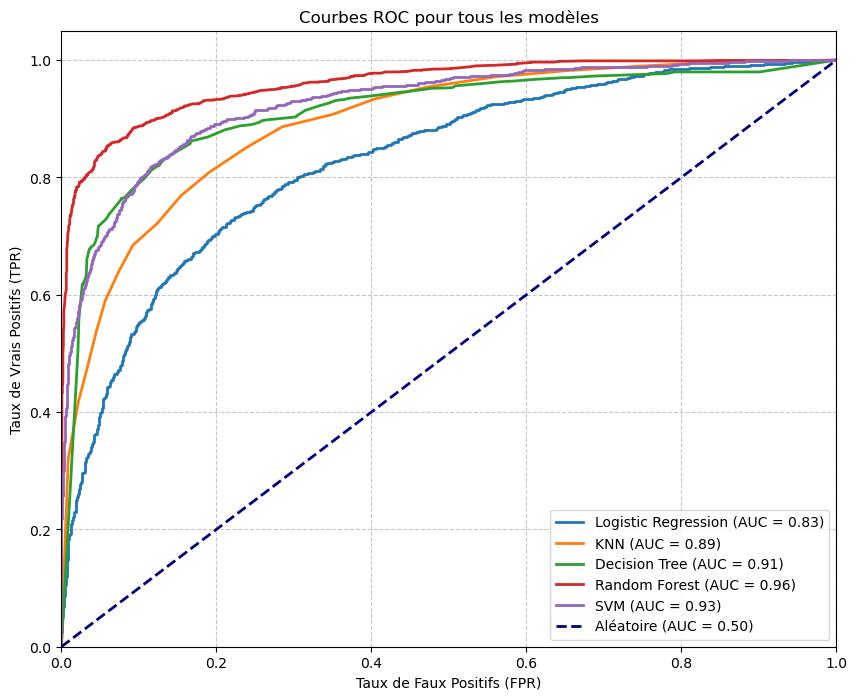

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Stocker les probabilités ou scores de décision pour chaque modèle
# Remarque: Pour SVM, on utilise decision_function car probability=True n'est pas activé par défaut
model_scores = {
    "Logistic Regression": Logistic.predict_proba(X_test)[:, 1],
    "KNN": knn.predict_proba(X_test)[:, 1],
    "Decision Tree": mdl.predict_proba(X_test)[:, 1],
    "Random Forest": rf_classifier.predict_proba(X_test)[:, 1],
    "SVM": SVM_.decision_function(X_test)
}

# Configuration de la figure
plt.figure(figsize=(10, 8))

# Tracer la courbe ROC pour chaque modèle
for model_name, y_score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Tracer la ligne diagonale de référence (Modèle aléatoire)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.50)')

# Personnalisation du graphique
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbes ROC pour tous les modèles')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)

# Afficher le graphique
plt.show()

<style>
    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
    }
</style>

<div class="eda-header">
    <h2>confusion matrix </h2>
    <div class="accent-line"></div>
</div>

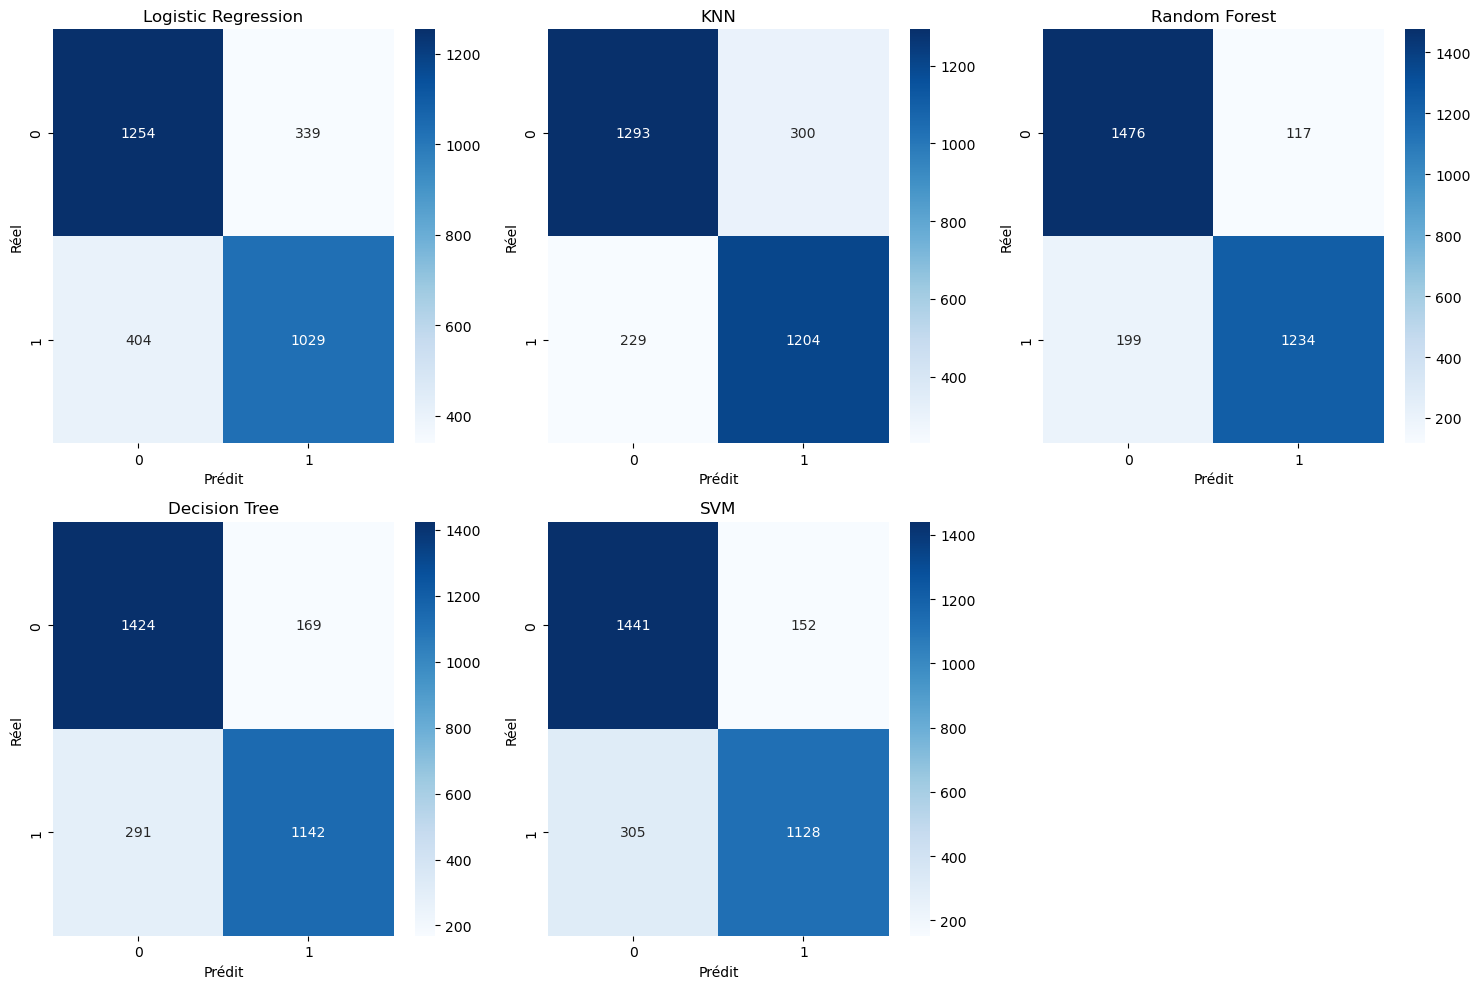

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')
axes[0, 0].set_xlabel('Prédit')
axes[0, 0].set_ylabel('Réel')

# KNN
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('KNN')
axes[0, 1].set_xlabel('Prédit')
axes[0, 1].set_ylabel('Réel')

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_title('Random Forest')
axes[0, 2].set_xlabel('Prédit')
axes[0, 2].set_ylabel('Réel')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_mdl), annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Decision Tree')
axes[1, 0].set_xlabel('Prédit')
axes[1, 0].set_ylabel('Réel')

# SVM
sns.heatmap(confusion_matrix(y_test, Y_pred_svm), annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('SVM')
axes[1, 1].set_xlabel('Prédit')
axes[1, 1].set_ylabel('Réel')

# Remove the last empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

In [59]:
import joblib
joblib.dump(rf_classifier, 'random_forest_model.pkl')

print("Modèle sauvegardé avec succès sous le nom 'random_forest_model.pkl' !")

Modèle sauvegardé avec succès sous le nom 'random_forest_model.pkl' !


In [ ]:
import joblib

joblib.dump(rf_classifier, 'random_forest_model.pkl', compress=3)
print("Compressed model saved successfully!")

Compressed model saved successfully!


### lien de Kaggel : <https://www.kaggle.com/code/alaeikhlas256/randomclient>

### lien de GitHub : <https://github.com/ikhlasalae9-beep/churn_bank2>

### lien de application streamilt : <https://churnbank2-rb5s8yd78c6vgqr86recdg.streamlit.app/>